Dhaivat Jani <br>
202511053 <br>
Lab 03 - CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


# Task 1 – Data Preparation 

In [3]:
CSV_PATH = 'D:\College\DAU\Sem 02\Deep Learning\Lab03\Data\data.csv'          
IMG_DIR = 'D:\College\DAU\Sem 02\Deep Learning\Lab03\Data\sampled_images'    
IMG_SIZE = (224, 224)         
BATCH_SIZE = 32
NUM_EPOCHS_CNN = 20
NUM_EPOCHS_MOBILENET = 20
LR = 1e-3

## CSV

In [4]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
df.shape

(6000, 9)

In [5]:
df.head()

,Filename,AQI,PM2.5,PM10,O3,CO,SO2,NO2,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,32,13.0,32.0,31.0,219.0,10.0,20.0,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,43,22.0,40.0,36.0,268.0,16.0,7.0,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,47,24.0,46.0,19.0,216.0,8.0,14.0,a_Good


In [6]:
df = df[['Filename', 'AQI_Class']].rename(columns={'Filename': 'image_path'})
df['AQI_Class'] = df['AQI_Class'].str.strip()

print(df['AQI_Class'].value_counts())

AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


In [7]:
# Class encoding
classes     = sorted(df['AQI_Class'].unique())
class2idx   = {c: i for i, c in enumerate(classes)}
idx2class   = {i: c for c, i in class2idx.items()}
NUM_CLASSES = len(classes)

print(f'\nNumber of classes: {NUM_CLASSES}')
print('Class mapping:', class2idx)


Number of classes: 6
Class mapping: {'a_Good': 0, 'b_Moderate': 1, 'c_Unhealthy_for_Sensitive_Groups': 2, 'd_Unhealthy': 3, 'e_Very_Unhealthy': 4, 'f_Severe': 5}


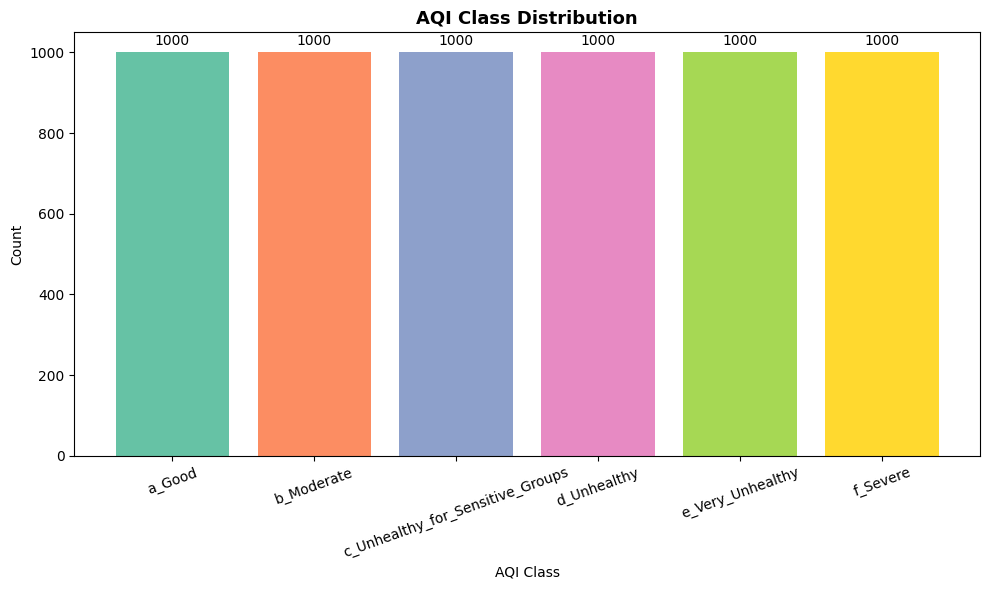

In [8]:
import matplotlib.pyplot as plt

# Visualise class distribution
fig, ax = plt.subplots(figsize=(10, 6))
counts = df['AQI_Class'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=plt.cm.Set2.colors[:len(counts)])
ax.bar_label(bars, padding=3)
ax.set_title('AQI Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('AQI Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

df['label'] = df['AQI_Class'].map(class2idx)

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f'Train : {len(train_df):>5} samples')
print(f'Val   : {len(val_df):>5} samples')
print(f'Test  : {len(test_df):>5} samples')

Train :  4200 samples
Val   :   900 samples
Test  :   900 samples


## Dataset & DataLoaders

In [10]:
import os

class AQIDataset(Dataset):
    """Loads AQI images and returns (tensor, label) pairs."""

    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_path'])
        label    = int(row['label'])
        try:
            img = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            # Return a black image if the file is missing
            img = Image.new('RGB', IMG_SIZE, color=(0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

In [11]:
from PIL import Image

# ── Step 1: Compute mean and std from the training set ──────────────────────

# Minimal transform – just resize and convert to tensor (no normalization yet)
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # scales pixels to [0, 1]
])

raw_dataset = AQIDataset(train_df, IMG_DIR, transform=raw_transform)
raw_loader  = DataLoader(raw_dataset, batch_size=500, shuffle=False, num_workers=0)

mean = torch.zeros(3)
std  = torch.zeros(3)
n_samples = 0

for imgs, _ in raw_loader:
    # imgs shape: (B, C, H, W)
    batch_size = imgs.size(0)
    imgs = imgs.view(batch_size, 3, -1)          # (B, C, H*W)
    mean += imgs.mean(dim=2).sum(dim=0)          # sum over batch
    std  += imgs.std(dim=2).sum(dim=0)
    n_samples += batch_size

mean /= n_samples
std  /= n_samples

print(f"Dataset Mean : {mean.tolist()}")
print(f"Dataset Std  : {std.tolist()}")

Dataset Mean : [0.542869508266449, 0.5777507424354553, 0.6007159352302551]
Dataset Std  : [0.19785547256469727, 0.19689413905143738, 0.2104116529226303]


In [12]:
mean = [0.542869508266449, 0.5777507424354553, 0.6007159352302551]
std = [0.19785547256469727, 0.19689413905143738, 0.2104116529226303]

In [13]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std =std),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std =std),
])

In [14]:
train_dataset = AQIDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = AQIDataset(val_df,   IMG_DIR, transform=eval_transform)
test_dataset  = AQIDataset(test_df,  IMG_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [15]:
print("Train Batches :: ", len(train_loader))
print("Val Batches :: ", len(val_loader))
print("Test Batches :: ", len(test_loader))

Train Batches ::  132
Val Batches ::  29
Test Batches ::  29


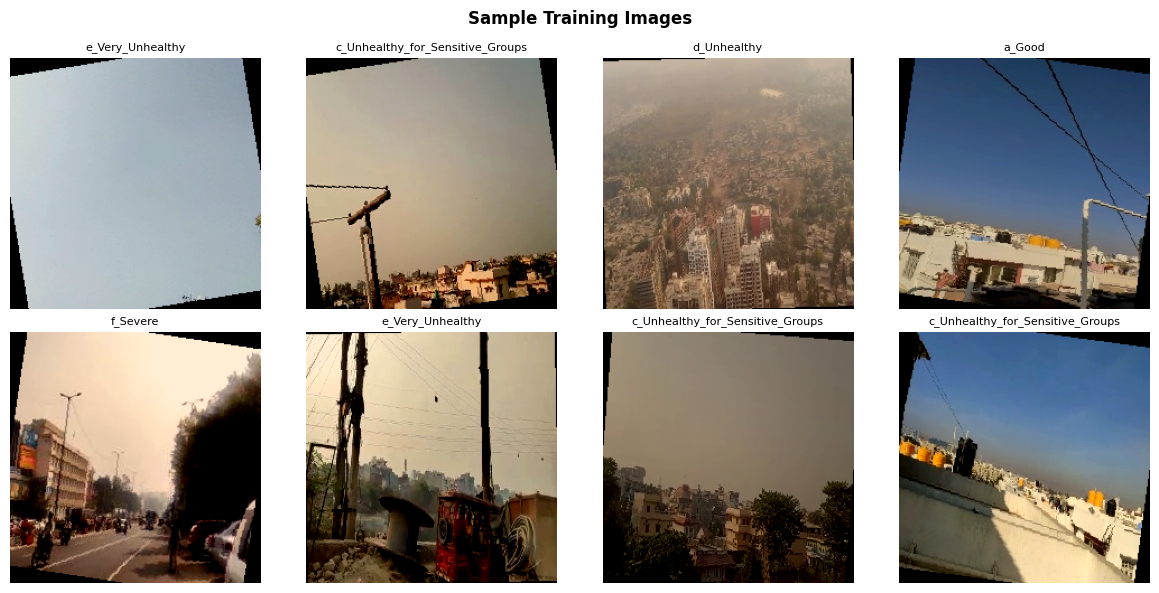

In [16]:
# Visualise a few sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for ax, (img_tensor, label) in zip(axes.flat, train_dataset):
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)
    ax.imshow(img_np)
    ax.set_title(idx2class[label], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Training

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

## Evaluate

In [18]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item() * imgs.size(0)
            preds        = outputs.argmax(dim=1)
            correct     += (preds == labels).sum().item()
            total       += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

## Tarining Loop

In [19]:
import sys

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs, device, model_name='model'):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')

        print(f'[{model_name}] Epoch {epoch:>3}/{num_epochs}  '
              f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
              f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}')
        sys.stdout.flush()

    print(f'Best Val Acc: {best_val_acc:.4f}')
    return history

# Task 2 – Basic CNN Model 

In [20]:
class BasicCNN(nn.Module):
    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            self._conv_block(3,  32),   # 224 -> 112
            self._conv_block(32, 64),   # 112 -> 56
            self._conv_block(64, 128),  # 56  -> 28
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

cnn_model = BasicCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 619,558


In [21]:
from torchinfo import summary

summary(cnn_model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
BasicCNN                                 [1, 6]                    --
├─Sequential: 1-1                        [1, 128, 28, 28]          --
│    └─Sequential: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                  [1, 32, 224, 224]         864
│    │    └─BatchNorm2d: 3-2             [1, 32, 224, 224]         64
│    │    └─ReLU: 3-3                    [1, 32, 224, 224]         --
│    │    └─MaxPool2d: 3-4               [1, 32, 112, 112]         --
│    │    └─Dropout2d: 3-5               [1, 32, 112, 112]         --
│    └─Sequential: 2-2                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-6                  [1, 64, 112, 112]         18,432
│    │    └─BatchNorm2d: 3-7             [1, 64, 112, 112]         128
│    │    └─ReLU: 3-8                    [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-9               [1, 64, 56, 56]           --
│    │   

In [22]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LR, weight_decay=1e-4)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', patience=3, factor=0.5
)

cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    cnn_criterion, cnn_optimizer, cnn_scheduler,
    num_epochs=NUM_EPOCHS_CNN, device=DEVICE, model_name='basic_cnn'
)

[basic_cnn] Epoch   1/20  Train Loss: 1.5670  Train Acc: 0.3612  Val Loss: 1.2648  Val Acc: 0.4767
[basic_cnn] Epoch   2/20  Train Loss: 1.4212  Train Acc: 0.4133  Val Loss: 1.1947  Val Acc: 0.5122
[basic_cnn] Epoch   3/20  Train Loss: 1.3198  Train Acc: 0.4662  Val Loss: 1.1833  Val Acc: 0.5211
[basic_cnn] Epoch   4/20  Train Loss: 1.2793  Train Acc: 0.4690  Val Loss: 1.0374  Val Acc: 0.5478
[basic_cnn] Epoch   5/20  Train Loss: 1.2326  Train Acc: 0.4983  Val Loss: 0.9953  Val Acc: 0.5744
[basic_cnn] Epoch   6/20  Train Loss: 1.1993  Train Acc: 0.5088  Val Loss: 0.9551  Val Acc: 0.5911
[basic_cnn] Epoch   7/20  Train Loss: 1.1479  Train Acc: 0.5260  Val Loss: 0.8894  Val Acc: 0.6422
[basic_cnn] Epoch   8/20  Train Loss: 1.1265  Train Acc: 0.5452  Val Loss: 0.8492  Val Acc: 0.6522
[basic_cnn] Epoch   9/20  Train Loss: 1.0951  Train Acc: 0.5521  Val Loss: 0.8343  Val Acc: 0.6556
[basic_cnn] Epoch  10/20  Train Loss: 1.0760  Train Acc: 0.5624  Val Loss: 0.8132  Val Acc: 0.6567
[basic_cnn

# Task 3 – Pretrained CNN Model (Transfer Learning)

In [23]:
# Load MobileNetV2 pretrained on ImageNet
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in mobilenet.features.parameters():
    param.requires_grad = False

# Replace the final classifier head to match NUM_CLASSES
in_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES),
)
mobilenet = mobilenet.to(DEVICE)

# Trainable params
total_params = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f'Trainable parameters (classifier only): {total_params:,}')

Trainable parameters (classifier only): 329,478


In [24]:
mn_criterion = nn.CrossEntropyLoss()

# Phase 1 – train classifier head only
mn_optimizer_phase1 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=LR, weight_decay=1e-4
)
mn_scheduler_phase1 = optim.lr_scheduler.ReduceLROnPlateau(
    mn_optimizer_phase1, mode='min', patience=3, factor=0.5
)

print('=== Phase 1: Training MobileNetV2 classifier head ===')
mn_history = train_model(
    mobilenet, train_loader, val_loader,
    mn_criterion, mn_optimizer_phase1, mn_scheduler_phase1,
    num_epochs=NUM_EPOCHS_MOBILENET, device=DEVICE, model_name='mobilenet'
)

=== Phase 1: Training MobileNetV2 classifier head ===
[mobilenet] Epoch   1/20  Train Loss: 1.3584  Train Acc: 0.4526  Val Loss: 0.9755  Val Acc: 0.6389
[mobilenet] Epoch   2/20  Train Loss: 1.0334  Train Acc: 0.5919  Val Loss: 0.8542  Val Acc: 0.6489
[mobilenet] Epoch   3/20  Train Loss: 0.9463  Train Acc: 0.6293  Val Loss: 0.7510  Val Acc: 0.7100
[mobilenet] Epoch   4/20  Train Loss: 0.8828  Train Acc: 0.6483  Val Loss: 0.7390  Val Acc: 0.6989
[mobilenet] Epoch   5/20  Train Loss: 0.8478  Train Acc: 0.6726  Val Loss: 0.7448  Val Acc: 0.7144
[mobilenet] Epoch   6/20  Train Loss: 0.8072  Train Acc: 0.6860  Val Loss: 0.6426  Val Acc: 0.7467
[mobilenet] Epoch   7/20  Train Loss: 0.7568  Train Acc: 0.7033  Val Loss: 0.7136  Val Acc: 0.7067
[mobilenet] Epoch   8/20  Train Loss: 0.7516  Train Acc: 0.7050  Val Loss: 0.5863  Val Acc: 0.7500
[mobilenet] Epoch   9/20  Train Loss: 0.7194  Train Acc: 0.7140  Val Loss: 0.5757  Val Acc: 0.7667
[mobilenet] Epoch  10/20  Train Loss: 0.6857  Train Acc

In [25]:
# Phase 2 – fine-tune last 3 feature blocks + classifier at lower LR
print('=== Phase 2: Fine-tuning last 3 feature blocks of MobileNetV2 ===')

for layer in list(mobilenet.features.children())[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

mn_optimizer_phase2 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=LR * 0.1, weight_decay=1e-4
)
mn_scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    mn_optimizer_phase2, mode='min', patience=3, factor=0.5
)

mn_history2 = train_model(
    mobilenet, train_loader, val_loader,
    mn_criterion, mn_optimizer_phase2, mn_scheduler_phase2,
    num_epochs=15, device=DEVICE, model_name='mobilenet'
)

# Merge histories
for k in mn_history:
    mn_history[k].extend(mn_history2[k])

=== Phase 2: Fine-tuning last 3 feature blocks of MobileNetV2 ===
[mobilenet] Epoch   1/15  Train Loss: 0.4857  Train Acc: 0.8095  Val Loss: 0.3198  Val Acc: 0.8822
[mobilenet] Epoch   2/15  Train Loss: 0.3756  Train Acc: 0.8555  Val Loss: 0.3207  Val Acc: 0.8778
[mobilenet] Epoch   3/15  Train Loss: 0.3350  Train Acc: 0.8702  Val Loss: 0.2878  Val Acc: 0.8900
[mobilenet] Epoch   4/15  Train Loss: 0.2830  Train Acc: 0.8950  Val Loss: 0.2613  Val Acc: 0.8900
[mobilenet] Epoch   5/15  Train Loss: 0.2736  Train Acc: 0.8948  Val Loss: 0.2225  Val Acc: 0.9089
[mobilenet] Epoch   6/15  Train Loss: 0.2279  Train Acc: 0.9155  Val Loss: 0.2157  Val Acc: 0.9178
[mobilenet] Epoch   7/15  Train Loss: 0.2205  Train Acc: 0.9179  Val Loss: 0.2127  Val Acc: 0.9267
[mobilenet] Epoch   8/15  Train Loss: 0.2012  Train Acc: 0.9269  Val Loss: 0.1646  Val Acc: 0.9400
[mobilenet] Epoch   9/15  Train Loss: 0.1910  Train Acc: 0.9314  Val Loss: 0.1602  Val Acc: 0.9400
[mobilenet] Epoch  10/15  Train Loss: 0.170

# Task 4 – Model Evaluation

In [26]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

def load_best_and_evaluate(model, model_name, test_loader, criterion, device, classes):
    """Load best saved checkpoint and run test evaluation."""
    model.load_state_dict(torch.load(f'best_{model_name}.pth', map_location=device))
    _, acc, preds, labels = evaluate(model, test_loader, criterion, device)

    print("=" * 60)
    print(f'  {model_name.upper()} – Test Results')
    print("=" * 60)
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision: {precision_score(labels, preds, average="weighted", zero_division=0):.4f}')
    print(f'  Recall   : {recall_score(labels,    preds, average="weighted", zero_division=0):.4f}')
    print(f'  F1-score : {f1_score(labels,        preds, average="weighted", zero_division=0):.4f}')
    print()
    print(classification_report(labels, preds, target_names=classes, zero_division=0))
    return preds, labels, acc

## Basic CNN

In [27]:
cnn_preds, cnn_labels, cnn_acc = load_best_and_evaluate(
    cnn_model, 'basic_cnn', test_loader, cnn_criterion, DEVICE, classes
)

  BASIC_CNN – Test Results
  Accuracy : 0.6789  (67.89%)
  Precision: 0.6744
  Recall   : 0.6789
  F1-score : 0.6687

                                  precision    recall  f1-score   support

                          a_Good       0.70      0.71      0.71       150
                      b_Moderate       0.63      0.76      0.69       150
c_Unhealthy_for_Sensitive_Groups       0.47      0.28      0.35       150
                     d_Unhealthy       0.56      0.69      0.62       150
                e_Very_Unhealthy       0.86      0.71      0.78       150
                        f_Severe       0.83      0.91      0.87       150

                        accuracy                           0.68       900
                       macro avg       0.67      0.68      0.67       900
                    weighted avg       0.67      0.68      0.67       900



## MobileNet

In [28]:
mn_preds, mn_labels, mn_acc = load_best_and_evaluate(
    mobilenet, 'mobilenet', test_loader, mn_criterion, DEVICE, classes
)

  MOBILENET – Test Results
  Accuracy : 0.9511  (95.11%)
  Precision: 0.9512
  Recall   : 0.9511
  F1-score : 0.9510

                                  precision    recall  f1-score   support

                          a_Good       0.94      0.93      0.94       150
                      b_Moderate       0.92      0.94      0.93       150
c_Unhealthy_for_Sensitive_Groups       0.97      0.93      0.95       150
                     d_Unhealthy       0.95      0.97      0.96       150
                e_Very_Unhealthy       0.96      0.93      0.95       150
                        f_Severe       0.97      0.99      0.98       150

                        accuracy                           0.95       900
                       macro avg       0.95      0.95      0.95       900
                    weighted avg       0.95      0.95      0.95       900



## Confusion Matrices

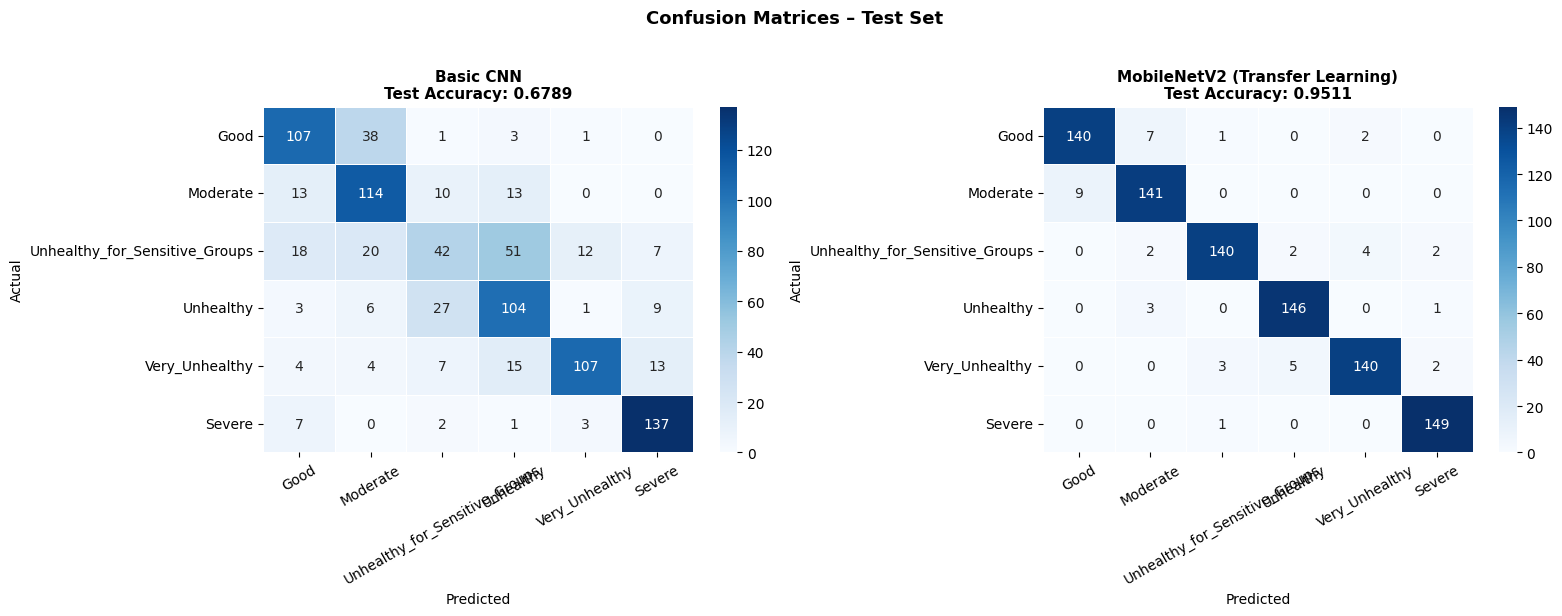

In [42]:
import seaborn as sns

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short_classes = [c.split('_', 1)[1] for c in classes]

for ax, preds, labels, title in zip(
    axes,
    [cnn_preds, mn_preds],
    [cnn_labels, mn_labels],
    ['Basic CNN', 'MobileNetV2 (Transfer Learning)']
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=short_classes, yticklabels=short_classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'{title}\nTest Accuracy: {accuracy_score(labels, preds):.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices – Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Task 5 – Training Curves

In [30]:
def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val Loss')
    axes[0].set_title(f'{model_name} – Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=3, label='Train Acc')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=3, label='Val Acc')
    axes[1].set_title(f'{model_name} – Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Basic CNN

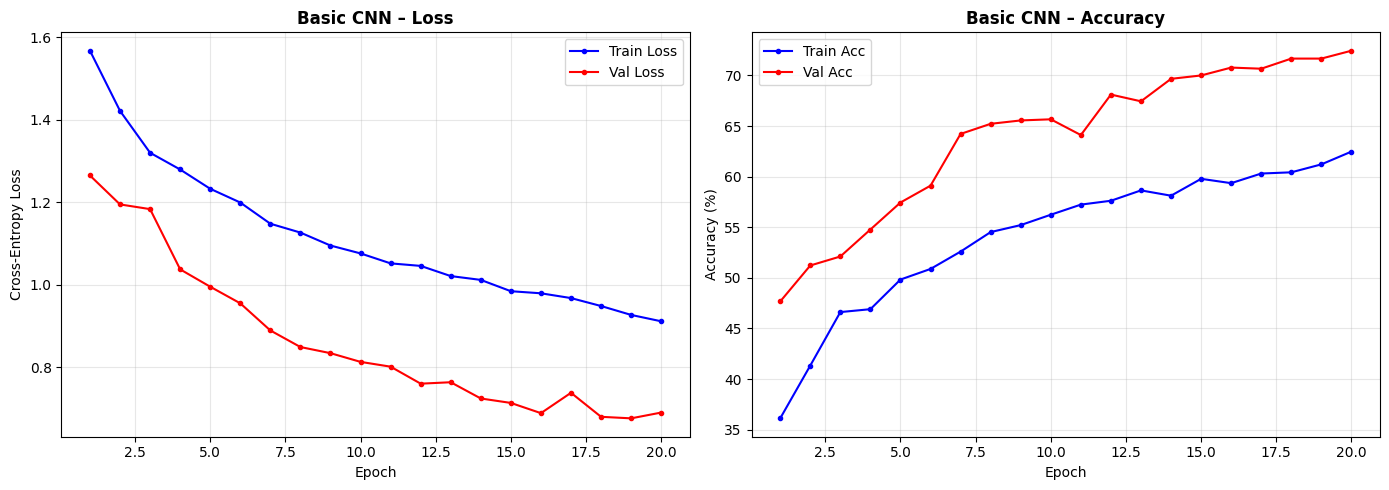

In [31]:
plot_training_curves(cnn_history, 'Basic CNN')

## MobileNet

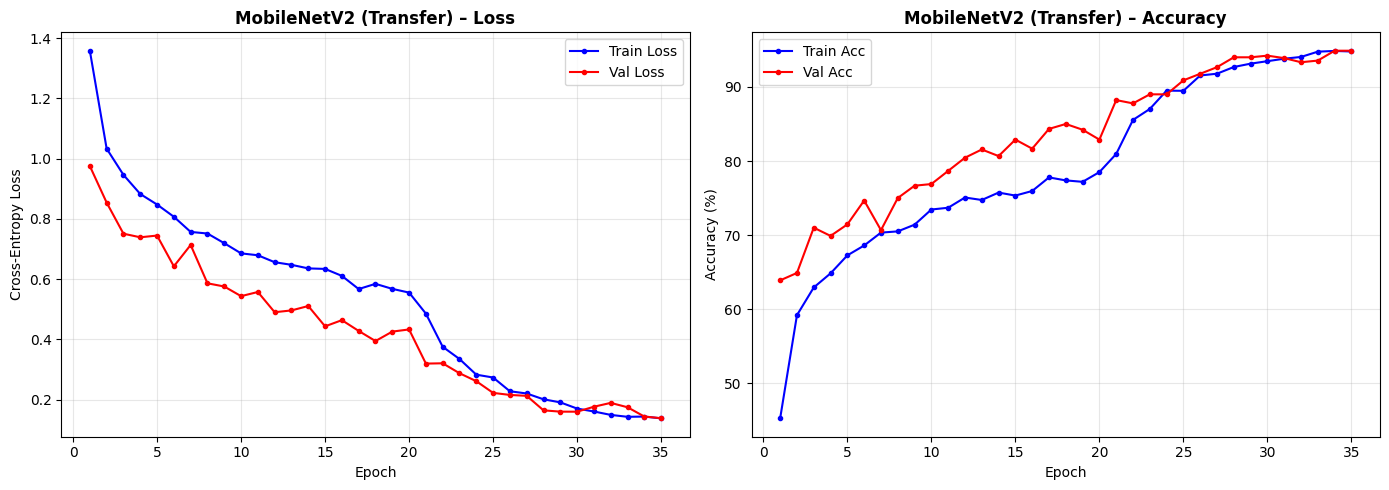

In [32]:
plot_training_curves(mn_history,  'MobileNetV2 (Transfer)')

## Accuracy Comparison

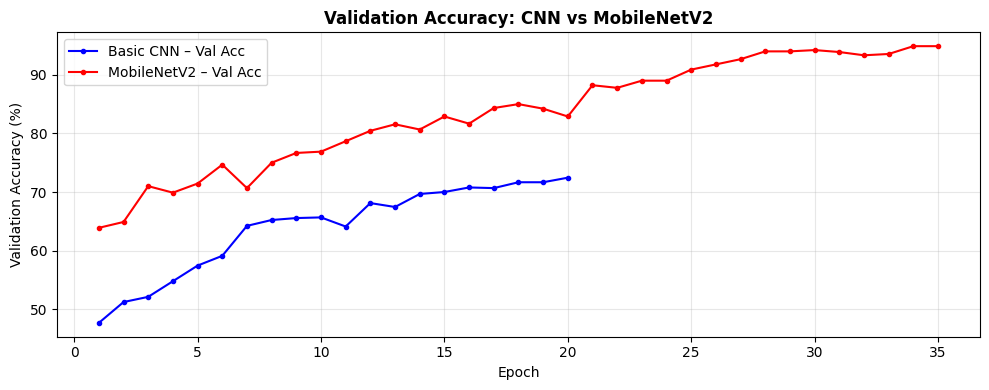

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
e_cnn = range(1, len(cnn_history['val_acc']) + 1)
e_mn  = range(1, len(mn_history['val_acc'])  + 1)
ax.plot(e_cnn, [a*100 for a in cnn_history['val_acc']], 'b-o', markersize=3, label='Basic CNN – Val Acc')
ax.plot(e_mn,  [a*100 for a in mn_history['val_acc']],  'r-o', markersize=3, label='MobileNetV2 – Val Acc')
ax.set_title('Validation Accuracy: CNN vs MobileNetV2', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 6 – Misclassification Analysis 

In [34]:
def get_misclassified(model, dataset, dataframe, device, n=10):
    """Return up to n misclassified samples with original images."""
    model.eval()
    misclassified = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            img_tensor, label = dataset[idx]
            output = model(img_tensor.unsqueeze(0).to(device))
            pred   = output.argmax(dim=1).item()
            if pred != label:
                # Load original (unnormalised) image
                img_path = os.path.join(IMG_DIR, dataframe.iloc[idx]['image_path'])
                try:
                    orig_img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
                except FileNotFoundError:
                    orig_img = Image.new('RGB', IMG_SIZE)
                misclassified.append({
                    'image'    : orig_img,
                    'actual'   : idx2class[label],
                    'predicted': idx2class[pred],
                    'idx'      : idx,
                })
            if len(misclassified) >= n:
                break
    return misclassified

In [35]:
print('Collecting misclassified samples for Basic CNN...')
cnn_misc = get_misclassified(
    cnn_model, test_dataset, test_df.reset_index(drop=True), DEVICE, n=10
)

In [36]:
print('Collecting misclassified samples for MobileNetV2...')
mn_misc = get_misclassified(
    mobilenet, test_dataset, test_df.reset_index(drop=True), DEVICE, n=10
)

In [37]:
def plot_misclassified(misclassified_list, model_name):
    n = len(misclassified_list)
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
    axes = axes.flat

    for ax, sample in zip(axes, misclassified_list):
        ax.imshow(sample['image'])
        ax.set_title(
            f"Actual: {sample['actual'].split('_',1)[-1]}\n"
            f"Pred  : {sample['predicted'].split('_',1)[-1]}",
            fontsize=7.5, color='darkred', pad=8
        )
        ax.axis('off')

    for ax in list(axes)[n:]:
        ax.set_visible(False)

    plt.suptitle(f'Misclassified Images – {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0, w_pad=1.5)
    plt.show()

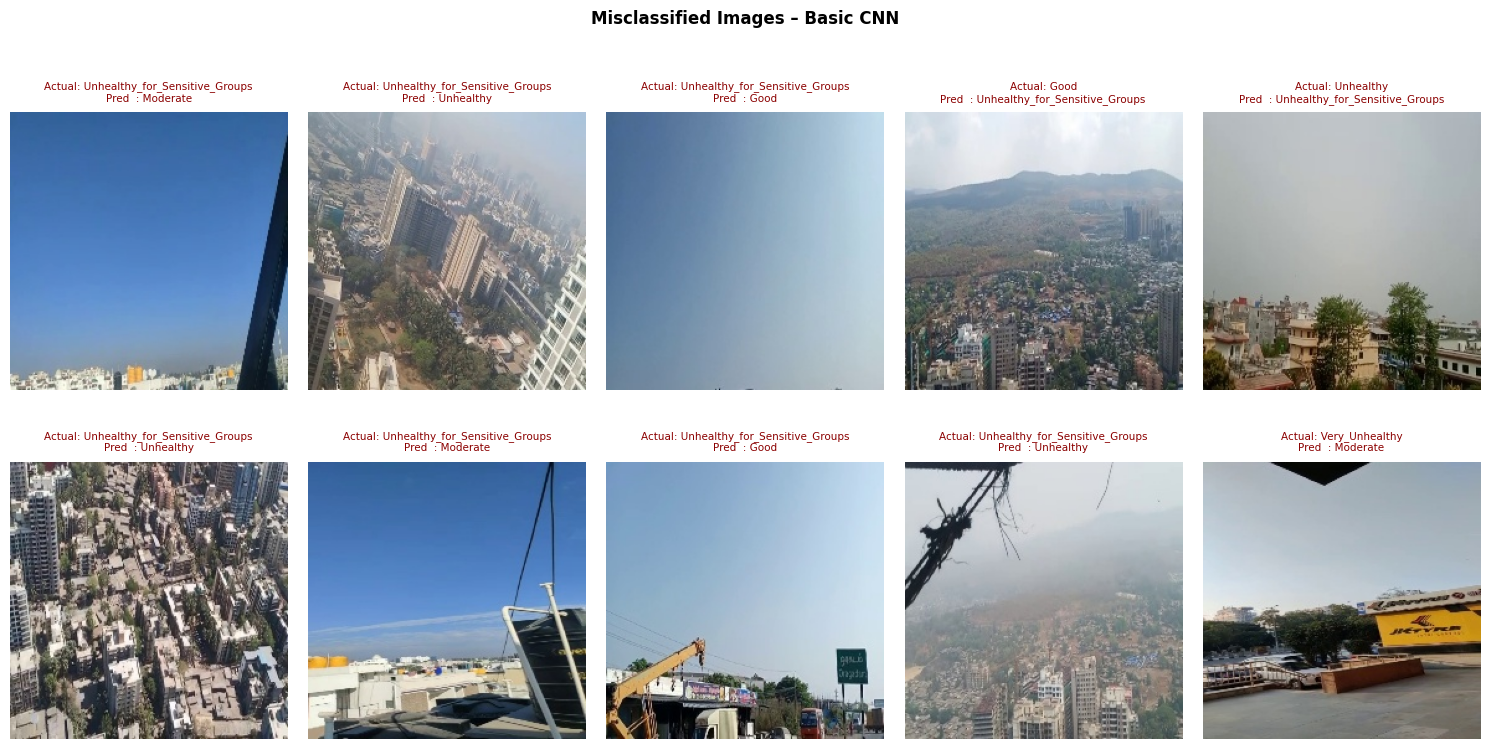

In [38]:
plot_misclassified(cnn_misc, 'Basic CNN')

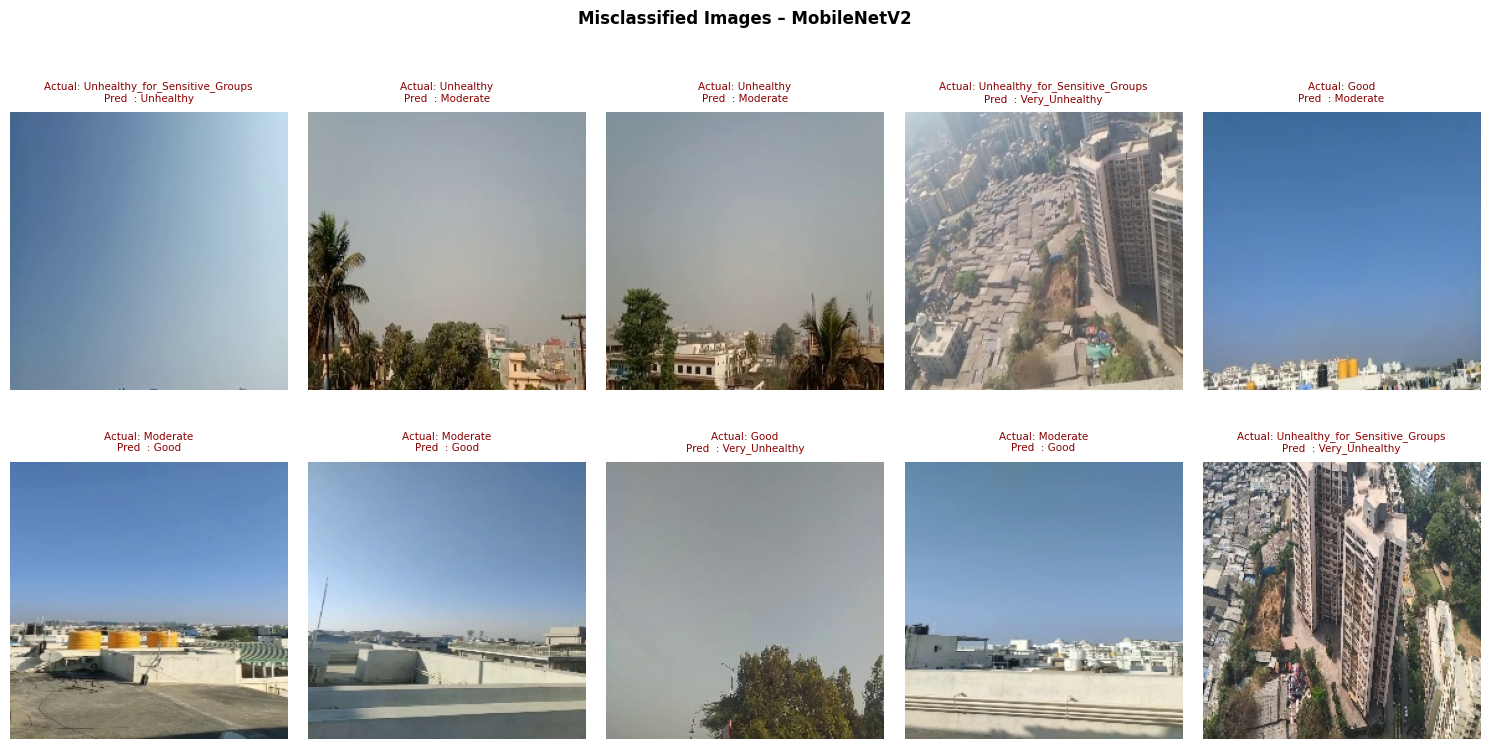

In [39]:
plot_misclassified(mn_misc,  'MobileNetV2')

In [40]:
results = {
    'Model'    : ['Basic CNN (Scratch)', 'MobileNetV2 (Transfer Learning)'],
    'Accuracy' : [
        round(accuracy_score(cnn_labels, cnn_preds), 4),
        round(accuracy_score(mn_labels,  mn_preds),  4),
    ],
    'Precision': [
        round(precision_score(cnn_labels, cnn_preds, average='weighted', zero_division=0), 4),
        round(precision_score(mn_labels,  mn_preds,  average='weighted', zero_division=0), 4),
    ],
    'Recall'   : [
        round(recall_score(cnn_labels, cnn_preds, average='weighted', zero_division=0), 4),
        round(recall_score(mn_labels,  mn_preds,  average='weighted', zero_division=0), 4),
    ],
    'F1-Score' : [
        round(f1_score(cnn_labels, cnn_preds, average='weighted', zero_division=0), 4),
        round(f1_score(mn_labels,  mn_preds,  average='weighted', zero_division=0), 4),
    ],
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Basic CNN (Scratch),0.6789,0.6744,0.6789,0.6687
1,MobileNetV2 (Transfer Learning),0.9511,0.9512,0.9511,0.9510


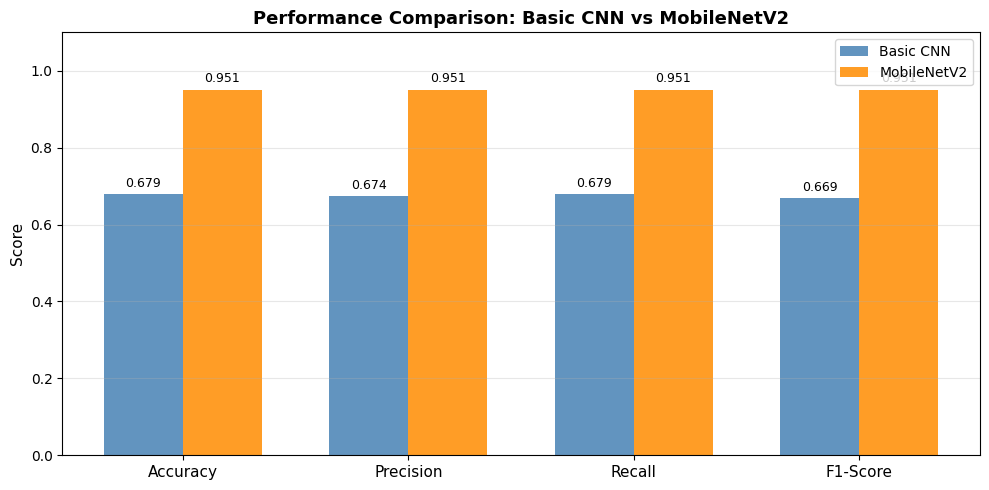

In [41]:
# Bar chart comparison
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_vals  = [results['Accuracy'][0], results['Precision'][0], results['Recall'][0], results['F1-Score'][0]]
mn_vals   = [results['Accuracy'][1], results['Precision'][1], results['Recall'][1], results['F1-Score'][1]]

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, cnn_vals, w, label='Basic CNN',         color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, mn_vals,  w, label='MobileNetV2',       color='darkorange', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Comparison: Basic CNN vs MobileNetV2', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()